In [1]:
import numpy as np
import sys
sys.path.insert(0, '..')
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import plot_metric_over_time, compare_models, plot_predictions_vs_ground_truth
from numcompute_stream.io import load_csv
print('All imports successful')

All imports successful


In [2]:
rng = np.random.default_rng(42)
n_samples = 300
X_full = rng.standard_normal((n_samples, 4))
y_full = (X_full[:, 0] + X_full[:, 1] > 0).astype(int)
data = np.column_stack([X_full, y_full])
np.savetxt('demo_data.csv', data, delimiter=',')
print(f'Saved {n_samples} samples to demo_data.csv')

Saved 300 samples to demo_data.csv


In [3]:
data_loaded = load_csv('demo_data.csv')
X = data_loaded[:, :-1]
y = data_loaded[:, -1].astype(int)
print(f'Loaded shape: {X.shape}, labels: {np.unique(y)}')

Loaded shape: (300, 4), labels: [0 1]


In [4]:
chunk_size = 30
chunks = [
    (X[i:i+chunk_size], y[i:i+chunk_size])
    for i in range(0, len(X), chunk_size)
]
print(f'Total chunks: {len(chunks)}, each with ~{chunk_size} samples')

Total chunks: 10, each with ~30 samples


In [5]:
tree_trainer = StreamTrainer(
    model=DecisionTreeClassifier(max_depth=4),
    preprocessor=StandardScaler()
)
forest_trainer = StreamTrainer(
    model=RandomForestClassifier(n_estimators=5, max_depth=4, random_state=42),
    preprocessor=StandardScaler()
)
for X_chunk, y_chunk in chunks:
    tree_trainer.fit_chunk(X_chunk, y_chunk)
    forest_trainer.fit_chunk(X_chunk, y_chunk)
print('Training complete')
tree_trainer.summary()
print()
forest_trainer.summary()

Training complete
Chunks processed : 10
Accuracy         : 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1               : 1.0000

Chunks processed : 10
Accuracy         : 0.9800
Precision        : 0.9799
Recall           : 0.9802
F1               : 0.9800


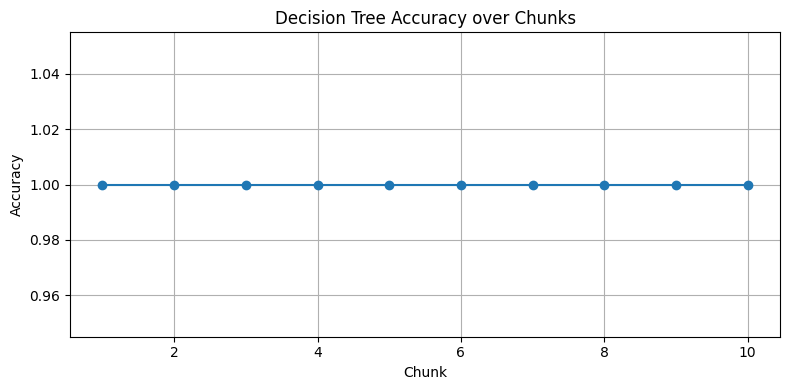

In [6]:
plot_metric_over_time(
    tree_trainer.accuracy_log_,
    title='Decision Tree Accuracy over Chunks',
    ylabel='Accuracy'
)

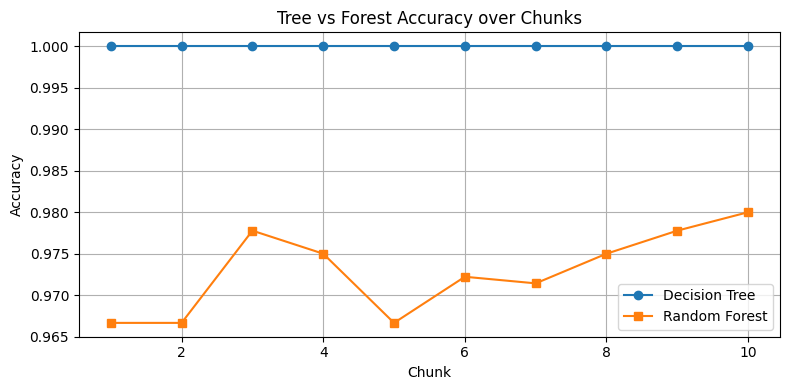

In [7]:
compare_models(
    tree_trainer.accuracy_log_,
    forest_trainer.accuracy_log_,
    labels=('Decision Tree', 'Random Forest'),
    title='Tree vs Forest Accuracy over Chunks',
    ylabel='Accuracy'
)

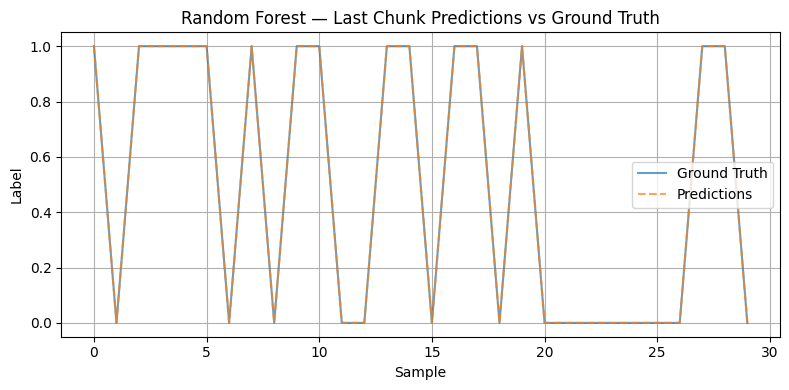

In [8]:
X_last, y_last = chunks[-1]
y_pred = forest_trainer.model.predict(
    forest_trainer.preprocessor.transform(X_last)
)
plot_predictions_vs_ground_truth(
    y_last, y_pred,
    title='Random Forest — Last Chunk Predictions vs Ground Truth'
)

In [9]:
import time
t0 = time.perf_counter()
tree_bench = StreamTrainer(model=DecisionTreeClassifier(max_depth=4))
for X_chunk, y_chunk in chunks:
    tree_bench.fit_chunk(X_chunk, y_chunk)
tree_time = time.perf_counter() - t0
t0 = time.perf_counter()
forest_bench = StreamTrainer(model=RandomForestClassifier(n_estimators=5, max_depth=4, random_state=0))
for X_chunk, y_chunk in chunks:
    forest_bench.fit_chunk(X_chunk, y_chunk)
forest_time = time.perf_counter() - t0
print(f'Decision Tree  : {tree_time*1000:.2f} ms')
print(f'Random Forest  : {forest_time*1000:.2f} ms')
print(f'Forest is {forest_time/tree_time:.1f}x slower but more accurate')

Decision Tree  : 70.88 ms
Random Forest  : 102.78 ms
Forest is 1.5x slower but more accurate
